# ToDo
- Consider more features through data sourcing
- Interpreatation of user types

In [78]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Load prepared dataframes from pickle files
data_path = "../data_processed/"

with open(data_path + "df_prepared.pkl", "rb") as f:
    df = pickle.load(f)

with open(data_path + "merged_df_prepared.pkl", "rb") as f:
    merged_df = pickle.load(f)

print("DataFrames loaded successfully:")
print(f"  df shape: {df.shape}")
print(f"  merged_df shape: {merged_df.shape}")

DataFrames loaded successfully:
  df shape: (65006, 21)
  merged_df shape: (65006, 27)


# Cluster Analysis

To conduct a clustering of the registered users, we first need to extract all session with a registered user and store these instances in a new variable

In [79]:
registered_users_df = merged_df[merged_df['isRegisteredUser'] == True].copy()

In [80]:
print(f"Total sessions in merged_df: {len(merged_df)}")
print(f"Sessions from registered users: {len(registered_users_df)}")
print(f"Unique registered users to cluster: {registered_users_df['userID'].nunique()}")

Total sessions in merged_df: 65006
Sessions from registered users: 47815
Unique registered users to cluster: 1006


## Preprocessing
### Feature Selection for Clustering
We only considered numerical dimensions due to the nature of the KMeans Clustering. All categoric or time data can't be processed from here. Numerical data, which is dependend on other data is extracted through the delta to reduce redundance in the data itself.

In [81]:
cluster_df = registered_users_df[["kWhDelivered","charging_duration","minutesAvailable","userID"]].copy()
cluster_df["session_delta"] = registered_users_df["session_duration"] - registered_users_df["charging_duration"]
cluster_df["kWhRequested_delta"] = registered_users_df["kWhRequested"] - registered_users_df["kWhDelivered"]
cluster_df = cluster_df.groupby("userID").mean()

### 3-Sigma-Interval
As the cluster should represent only natural user behaviour data further out than 3 sigma is not considered. This data is rather due to extreme usage scenarios or failures in the data collection.

In [82]:
z_scores = (cluster_df - cluster_df.mean()) / cluster_df.std()
abs_z_scores = z_scores.abs()
filtered_entries = (abs_z_scores < 3).all(axis=1)
cluster_df_cleaned = cluster_df[filtered_entries]

### Data Scalling

In [83]:
std_scaler = StandardScaler()
std_scaler.set_output(transform="pandas")
cluster_scaled_df = std_scaler.fit_transform(cluster_df_cleaned)

## Estimation of number of clusters
The elbow method as well as silhoutte method is considered. The goal is to find a good trade of from both estimates

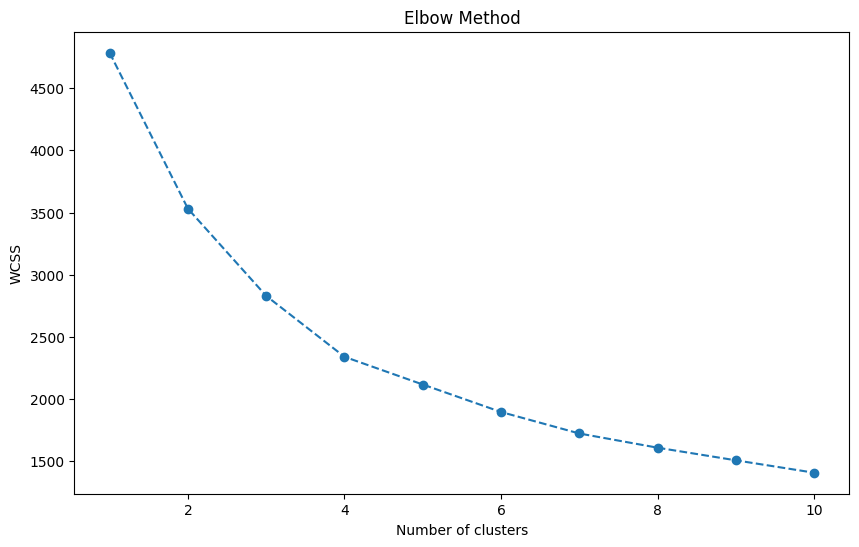

In [84]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(cluster_scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

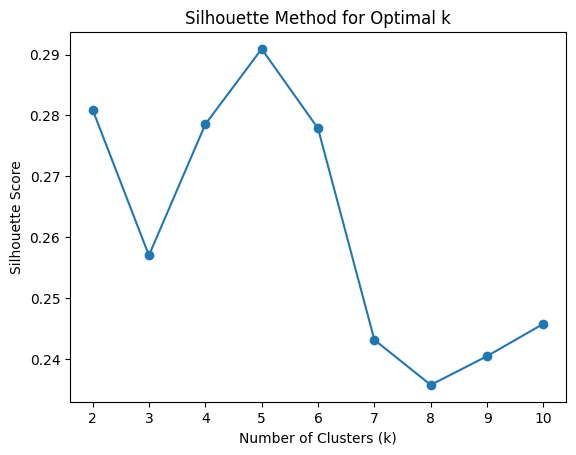

In [85]:
scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(cluster_scaled_df)
    score = silhouette_score(cluster_scaled_df, kmeans.labels_)
    scores.append(score)

plt.plot(k_range, scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.show()

## Application
The application of the KMeans alogrithm reveals different archityps of users, which differ from each other, but not in all dimensions.

### Interpretation
Cluster 1:  

Cluster 2:  

Cluster 3:  

Cluster 4:  

Cluster 5:

C:\Users\Robin\AppData\Local\Temp\ipykernel_26020\3648998166.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df_cleaned["kmeans_labels"] =kmeans_labels


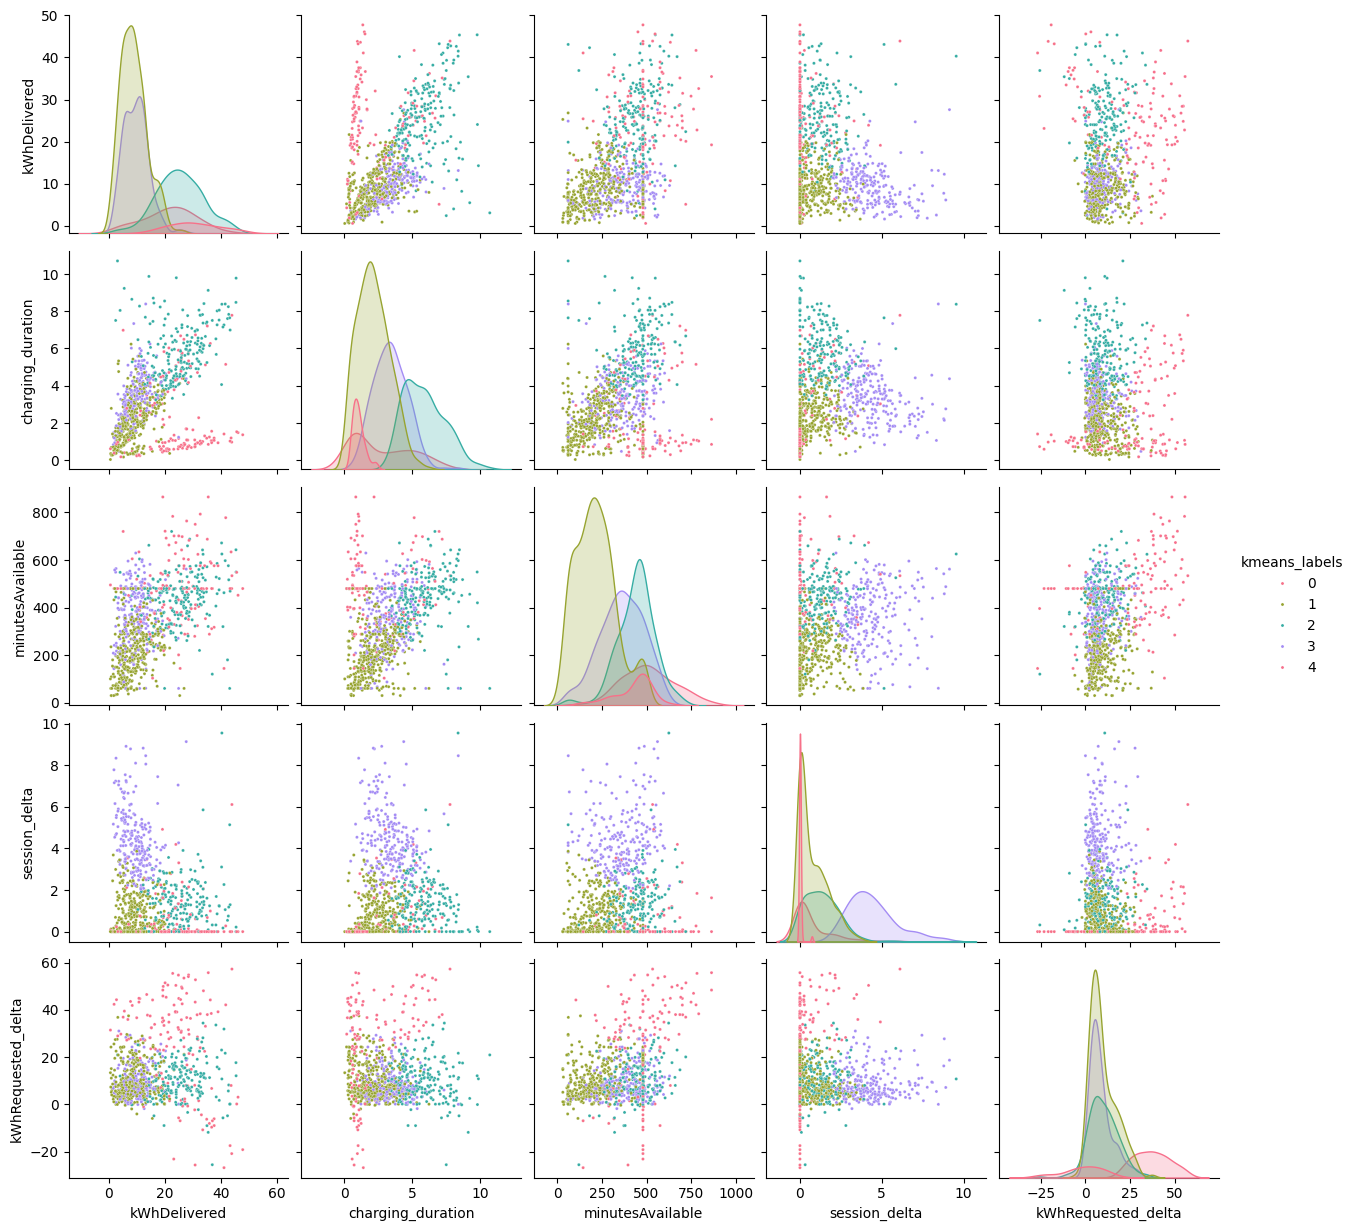

In [87]:
kmeans = KMeans(n_clusters=5)
kmeans_labels = kmeans.fit_predict(cluster_scaled_df)
cluster_df_cleaned["kmeans_labels"] =kmeans_labels

sns.pairplot(cluster_df_cleaned, hue="kmeans_labels", plot_kws={"s": 5}, palette='husl')
plt.savefig("../graphs/clustering.png")